# Gradient Descent for Linear Regression


In [2]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

## Problem Statement

use the same data points as before

In [3]:
# load in our data set
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

#### Compute Cost


In [4]:
# Function to calculate the cost
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0

    for i in range(m):
        cost += (w * x[i] + b - y[i]) ** 2

    return 1 / (2 * m) * cost

In [5]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    sum_w = 0
    sum_b = 0

    for i in range(m):
        sum_w += (w * x[i] + b - y[i]) * x[i]
        sum_b += w * x[i] + b - y[i]

    d_w = 1 / m * sum_w
    d_b = 1 / m * sum_b

    return d_w, d_b

Use ```compute_gradient``` to plot partia derivatives of the cost function

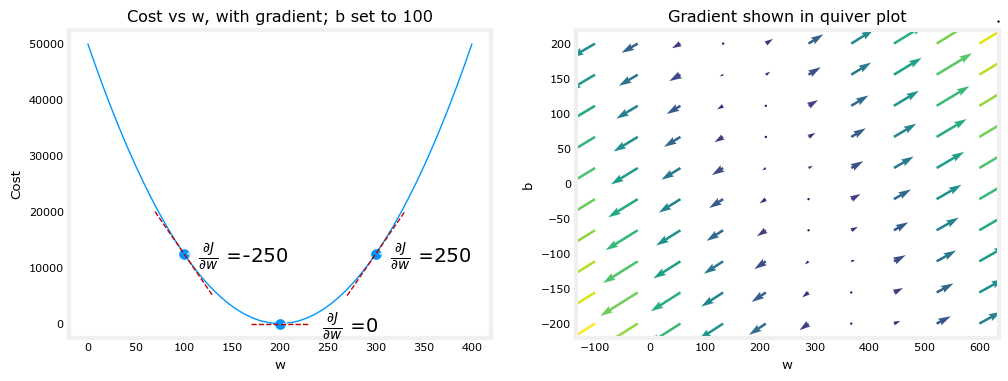

In [6]:
plt_gradients(x_train, y_train, compute_cost, compute_gradient)
plt.show()

### Gradient Descent Summary

The linear model that predicts $f_{w, b}(x ^{(i)})$:
\begin{equation}
f_{w, b}(x ^{(i)}) = wx^{(i)} + b
\end{equation}

The cost, $J(w, b)$, is given by the equation:
$$J(w, b) = \dfrac{1}{2m} \sum_{i=0}^{m-1} \left( f_{w, b}(x^{(i)}) - y^{(i)} \right)^2$$

Gradient descent is described as:
$$ w = w - \alpha \frac{\partial J(w, b)}{\partial w} $$
$$ b = b - \alpha \frac{\partial J(w, b)}{\partial b} $$

Gradient defined as:
$$ \begin{align*}
\frac{\partial J(w,b)}{\partial w} &= \frac{1}{m}\sum_{i=0}^{m-1}(f_{w,b}(\boldsymbol{x}^{(i)}) - y^{(i)})\boldsymbol{x}^{(i)} \\
\frac{\partial J(w,b)}{\partial b} &= \frac{1}{m}\sum_{i=0}^{m-1}(f_{w,b}(\boldsymbol{x}^{(i)}) - y^{(i)})
\end{align*}
 $$


In [14]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_func, gradient_func):
    """
    Performs gradient descent to fit w, b. 
    Updates w, b by taking num_iters steps with learning rate alpha.

    Args:
        x (ndarray (m,)) : data, m examples
        y (ndarray (m,)) : target values
        w_in, b_in (scalar) : initial values of model parameters
        alpha (float) : learning rate
        num_iters (int) : number of iterations to run gradient descent
        cost_function : function to call to produce cost
        gradient_function: function to call to produce gradient

    Returns:
        w (scalar): Updated value of parameter after running gradient descent
        b (scalar): Updated value of parameter after running gradient descent
        J_history (List): History of cost values
        p_history (list): History of parameters [w,b] 
    """
    J_history = []
    p_history = []
    w = w_in
    b = b_in

    for i in range(num_iters):
        d_w, d_b = gradient_func(x, y, w, b)
        w = w - alpha * d_w 
        b = b - alpha * d_b

        if i < 100000:
            J_history.append(cost_func(x, y, w, b))
            p_history.append([w, b])
            
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {d_w: 0.3e}, dj_db: {d_b: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")


    return w, b, J_history, p_history                 

In [15]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration 1000: Cost 3.41e+00  dj_dw: -3.712e-01, dj_db:  6.007e-01   w:  1.949e+02, b: 1.08228e+02
Iteration 2000: Cost 7.93e-01  dj_dw: -1.789e-01, dj_db:  2.895e-01   w:  1.975e+02, b: 1.03966e+02
Iteration 3000: Cost 1.84e-01  dj_dw: -8.625e-02, dj_db:  1.396e-01   w:  1.988e+02, b: 1.01912e+02
Iteration 4000: Cost 4.28e-02  dj_dw: -4.158e-02, dj_db:  6.727e-02   w:  1.994e+02, b: 1.00922e+02
Iteration 5000: Cost 9.95e-03  dj_dw: -2.004e-02, dj_db:  3.243e-02   w:  1.997e+02, b: 1.00444e+02
Iteration 6000: Cost 2.31e-03  dj_dw: -9.660e-03, dj_db:  1.563e-02   w:  1.999e+02, b: 1.00214e+02
Iteration 7000: Cost 5.37e-04  dj_dw: -4.657e-03, dj_db:  7.535e-03   w:  1.999e+02, b: 1.00103e+02
Iteration 8000: Cost 1.25e-04  dj_dw: -2.245e-03, dj_db:  3.632e-03   w:  2.000e+02, b: 1.00050e+02
Iteration 9000: Cost 2.90e-05  dj_dw: -1.082e-03, dj_db:  1.751e-03   w:  2.000e+02, b: 1.00024e+02
